**непараметрическая регрессия**

Евгений Борисов esborisov@sevsu.ru

# загружаем данные

In [1]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
display( data.keys() )

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [2]:
print( data['DESCR'] )

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
display( data['frame'].sample(3) )

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
13027,4.0500,20.0,6.220264,0.995595,700.0,3.083700,38.67,-121.22,1.307
18501,15.0001,52.0,8.461538,1.230769,55.0,2.115385,37.19,-121.59,1.313
7665,4.1250,5.0,5.734177,1.183544,1453.0,9.196203,33.93,-118.07,1.719


# обработка геометки

https://geopandas.org/en/stable/getting_started/introduction.html

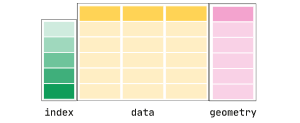

In [4]:
import geopandas as gpd
from shapely.geometry import MultiPoint

In [5]:
gdf = gpd.GeoDataFrame(
        data['frame'],
        geometry=gpd.points_from_xy( data['frame']['Longitude'], data['frame']['Latitude'] ), 
        crs='epsg:4326'
    )

display( len(gdf) )
display( gdf.sample(3) )

20640

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,geometry
1957,2.9844,31.0,5.301020,1.047619,1606.0,2.731293,38.73,-120.78,1.279,POINT (-120.78 38.73)
19797,1.9034,27.0,4.766667,1.093939,847.0,2.566667,40.54,-123.22,0.496,POINT (-123.22 40.54)
6076,3.8167,21.0,6.149740,1.148438,2210.0,2.877604,34.07,-117.87,2.587,POINT (-117.87 34.07)


In [6]:
del data


----

In [7]:
# загружем геоданные по административным границам 

#  https://data.ca.gov/dataset/ca-geographic-boundaries 
# -> CA Places Boundaries

gdf_calif = gpd.read_file('../data/ca_places.zip')[['NAME','geometry']]
display(len(gdf_calif))
display(gdf_calif.sample(3))

1521

,NAME,geometry
1361,Ponderosa,"POLYGON ((-13195853.896 4316079.336, -13195179..."
1454,Walnut Grove,"POLYGON ((-13533063.646 4613484.965, -13533015..."
481,Plymouth,"MULTIPOLYGON (((-13452002.119 4647758.462, -13..."


In [9]:
# gdf_calif.explore()

---

In [10]:
# добавляем геоданные административных границ к геометкам объектов

display(len(gdf))

gdf_ = gdf_calif[['NAME','geometry']].sjoin(
        gdf.to_crs(gdf_calif.crs), 
        how='inner'
    ).rename(columns={'index_right':'point_idx','NAME':'district_name'})

display(len(gdf_))
display(gdf_.sample(3))

20640

18017

,district_name,geometry,point_idx,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
91,Rosemead,"POLYGON ((-13147735.795 4037206.593, -13147645...",6818,2.9688,43.0,4.445596,1.041451,1343.0,3.479275,34.08,-118.08,2.114
365,Escondido,"MULTIPOLYGON (((-13027022.804 3919301.507, -13...",15531,4.4655,7.0,6.148796,1.015317,1564.0,3.422319,33.15,-117.12,1.828
181,San Francisco,"MULTIPOLYGON (((-13649138.606 4553356.64, -136...",15953,3.7143,52.0,4.859155,0.957746,847.0,2.982394,37.72,-122.44,2.600


In [11]:
# медиана цены по районам
gdf_ = gpd.GeoDataFrame(
        gdf_[['district_name','MedHouseVal','geometry']]
        .groupby(['district_name','geometry'])
        ['MedHouseVal'].median()
        .reset_index()
    )

display(len(gdf_))
display(gdf_.sample(3))

985

,district_name,geometry,MedHouseVal
717,Redwood City,"MULTIPOLYGON (((-13609997.104 4504198.36, -136...",3.2530
727,Rio del Mar,"POLYGON ((-13570718.566 4434192.707, -13570647...",3.1495
584,Moss Beach,"POLYGON ((-13638852.903 4514012.491, -13638848...",3.6380


---

In [12]:
# # рисуем интерактивную карту
# gdf_.explore(
#         column='MedHouseVal', 
#         cmap='coolwarm', 
#         legend=True,
#         figsize=(11,11)
#     )

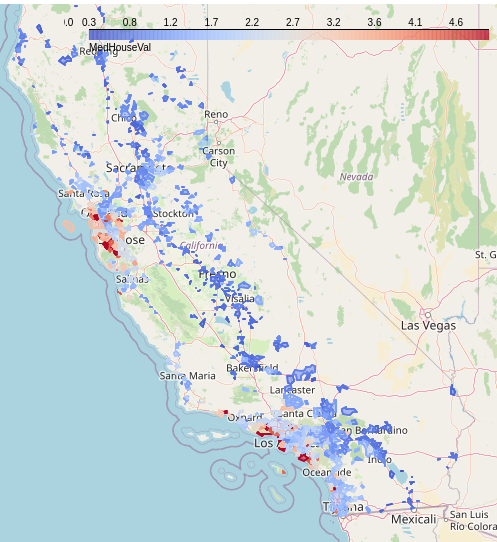

----

# строим модель регрессии

In [13]:
from sklearn.neighbors import KNeighborsRegressor

In [14]:
# будем предсказывать цену по вектору свойств объекта и геометке

col_features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
X,target = gdf[col_features].values, gdf['MedHouseVal'].values

# разделяем датасет на учебные и тестовые данные
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,target,test_size=.5)
display( ( X_train.shape, X_test.shape) )

del X, target

((10320, 8), (10320, 8))

In [15]:
# обучаем модель
model = KNeighborsRegressor().fit(X_train,y_train)

In [16]:
# оценка результатов

from sklearn.metrics import mean_squared_error

predicted = model.predict(X_test)
display( mean_squared_error(y_true=y_test, y_pred=predicted) )

1.1931618997829847

---

In [17]:
# запускаем поиск хороших сочетаний гиперпараметров модели
param_grid = { # списки значений гиперпараметров модели, которые будем тестировать
     'metric': ['euclidean','manhattan','chebyshev','minkowski','hamming','canberra','braycurtis',],
'n_neighbors': [1,5,9,16,32,128],
}

## полный перебор всех сочетаний гиперпараметров
# from sklearn.model_selection import GridSearchCV
#
# grid = GridSearchCV(
#         estimator=KNeighborsRegressor(),
#         param_grid=param_grid,
#         scoring='neg_mean_squared_error',
#     ).fit(X_train,y_train)


# ограниченный перебор случайных сочетаний гиперпараметров
from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
        estimator=KNeighborsRegressor(), 
        param_distributions=param_grid,
        scoring='neg_mean_squared_error',
        n_iter=5,
    ).fit(X_train,y_train)


# display( grid.best_score_ )
display( grid.best_params_ )

model_ = grid.best_estimator_

{'n_neighbors': 128, 'metric': 'braycurtis'}

In [18]:
# оценка результатов

predicted = model_.predict(X_test)
display( mean_squared_error(y_true=y_test, y_pred=predicted) )

1.2136231124302947

----

In [19]:
# !pip3 install watermark

In [20]:
%load_ext watermark
%watermark --python
%watermark --iversions

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 8.32.0

shapely  : 2.0.7
sklearn  : 1.6.1
geopandas: 1.1.1

